In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ---------------------------------------------------------
# 1. Synthetic Data Generation: A -> B -> C -> D -> Y
# ---------------------------------------------------------
def generate_causal_data(n=5000, anomaly=False):
    """
    Generates data where B is the root cause of an anomaly.
    """
    # A is an independent source
    A = np.random.normal(0, 1, n)
    # if anomaly:
    #     # Root Cause Anomaly: B is shifted by +3.0 independently of A
    #     A = 1.75 + np.random.normal(0, 0.1, n)
    # else:
    #     A = 2 + np.random.normal(0, 0.1, n)

    
    # B depends on A
    if anomaly:
        # Root Cause Anomaly: B is shifted by +3.0 independently of A
        B = np.tanh(A) + 0.5 + np.random.normal(0, 0.1, n)
    else:
        B = np.tanh(A) + np.random.normal(0, 0.1, n)
        
    # Downstream effects: C, D, Y follow their physical mechanisms
    C = B**3 + np.random.normal(0, 0.1, n)
    D = np.sin(C) + np.random.normal(0, 0.1, n)
    Y = D + np.random.normal(0, 0.1, n)
    
    data = np.stack([A, B, C, D, Y], axis=1)
    return torch.tensor(data, dtype=torch.float32)

# ---------------------------------------------------------
# 2. FlowNet Architecture (As provided by you)
# ---------------------------------------------------------
class FlowNet(nn.Module):
    def __init__(self, d=5, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), # +1 for time input
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, d)
        )

    def forward(self, x, t):
        h = torch.cat([x, t], dim=1)
        return self.net(h)

# ---------------------------------------------------------
# 3. Jacobian Autonomy Logic (The RCA "Engine")
# ---------------------------------------------------------
def run_jacobian_rca(net, x_abnormal, labels):
    """
    Ranks variables by their 'Autonomy' in the flow field.
    The Root Cause is the variable that drives its own correction 
    independently of the rest of the system.
    """
    net.eval()
    # Analyze a batch of abnormal points
    x_test = x_abnormal[:200].clone().detach().requires_grad_(True)
    t_test = torch.full((x_test.shape[0], 1), 0.5).to(x_test.device)
    
    # Get velocity vectors for the batch
    v = net(x_test, t_test)
    
    scores = []
    for i in range(len(labels)):
        # Compute gradient of v_i with respect to all input features (Row i of Jacobian)
        v_i_sum = v[:, i].sum()
        grad_v_i = torch.autograd.grad(v_i_sum, x_test, retain_graph=True)[0]
        
        # diag: |dv_i / dx_i| -> How much the node fixes itself
        diag = torch.abs(grad_v_i[:, i])
        # off_diag: sum(|dv_i / dx_j|) -> How much other nodes influence this node's fix
        off_diag = torch.abs(grad_v_i).sum(dim=1) - diag
        
        # Autonomy Score: Ratio of self-influence to external-influence
        # The Root Cause should have a high ratio (autonomous)
        # Downstream nodes will have low ratios (reactive)
        autonomy = diag / (off_diag + 1e-8)
        scores.append(autonomy.mean().item())
    
    return scores

# ---------------------------------------------------------
# 4. Main Execution Pipeline
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    labels = ['A', 'B', 'C', 'D', 'Y']
    
    # Prepare Tensors
    X_normal = generate_causal_data(anomaly=False).to(device)
    X_faulty = generate_causal_data(anomaly=True).to(device)

    # Initialize Model & Optimizer
    net = FlowNet(d=5).to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    
    # Training Loop
    print(f"Training Flow Matching on {device}...")
    n_steps = 5000
    batch_size = 64
    
    for step in range(n_steps):
        idx = torch.randint(0, len(X_normal), (batch_size,))
        x_f = X_faulty[idx] # Start
        x_n = X_normal[idx] # Target
        
        # Random time interpolation
        t = torch.rand(batch_size, 1).to(device)
        xt = (1 - t) * x_f + t * x_n
        v_target = x_n - x_f
        
        # Predict & Optimize
        v_pred = net(xt, t)
        loss = F.mse_loss(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if step % 2000 == 0:
            print(f"Step {step:4d} | Loss: {loss.item():.6f}")

    # --- Discovery Phase ---
    print("\n" + "="*35)
    print("      ROOT CAUSE ANALYSIS       ")
    print("="*35)
    
    scores = run_jacobian_rca(net, X_faulty, labels)
    results = sorted(zip(labels, scores), key=lambda x: x[1], reverse=True)
    
    for rank, (name, score) in enumerate(results, 1):
        indicator = "<-- [ROOT CAUSE]" if rank == 1 else ""
        print(f"Rank {rank}: {name:<3} | Score: {score:.4f} {indicator}")
    
    print("="*35)

Training Flow Matching on cuda...
Step    0 | Loss: 1.148400
Step 2000 | Loss: 0.416802
Step 4000 | Loss: 0.363942

      ROOT CAUSE ANALYSIS       
Rank 1: C   | Score: 0.6493 <-- [ROOT CAUSE]
Rank 2: B   | Score: 0.6309 
Rank 3: D   | Score: 0.2227 
Rank 4: A   | Score: 0.2135 
Rank 5: Y   | Score: 0.1411 


In [39]:
def run_trace_rca(net, x_abnormal, labels):
    net.eval()
    # Sample abnormal points
    x_test = x_abnormal[:200].clone().detach().requires_grad_(True)
    t_test = torch.full((x_test.shape[0], 1), 0.5).to(x_test.device)
    
    # Forward pass to get velocity
    v = net(x_test, t_test)
    
    trace_magnitudes = []
    
    for i in range(len(labels)):
        # Calculate row i of the Jacobian
        v_i_sum = v[:, i].sum()
        grad_v_i = torch.autograd.grad(v_i_sum, x_test, retain_graph=True)[0]
        
        # This is the 'raw diagonal magnitude' |dv_i / dx_i|
        # It represents the 'Local Divergence' or 'Force' applied to this variable
        diag_mean = torch.abs(grad_v_i[:, i]).mean().item()
        trace_magnitudes.append(diag_mean)
        
    return trace_magnitudes

# Execute and Print
trace_vals = run_trace_rca(net, X_faulty, labels)
for name, val in zip(labels, trace_vals):
    print(f"Variable {name} | Jacobian Trace Magnitude: {val:.6f}")

Variable A | Jacobian Trace Magnitude: 0.164544
Variable B | Jacobian Trace Magnitude: 0.126488
Variable C | Jacobian Trace Magnitude: 0.225130
Variable D | Jacobian Trace Magnitude: 0.091293
Variable Y | Jacobian Trace Magnitude: 0.120068


In [ ]:
def run_energy_rca(net, x_abnormal, labels):
    net.eval()
    x_test = x_abnormal[:200].clone().detach().requires_grad_(True)
    t_test = torch.full((x_test.shape[0], 1), 0.5).to(x_test.device)
    
    v = net(x_test, t_test)
    # print(v[:, 0] * t_test.view(-1))

    
    energy_scores = []
    for i in range(len(labels)):
        v_i = v[:, i]
        v_i_sum = v_i.sum()
        grad_v_i = torch.autograd.grad(v_i_sum, x_test, retain_graph=True)[0]
        
        # Energy = Average( |Velocity_i| * |Jacobian_ii| )
        # This filters out 'wiggly' variables that don't actually move far.
        diag = torch.abs(grad_v_i[:, i])
        energy = (torch.abs(v_i) * diag).mean().item()
        energy_scores.append(energy)
        
    return energy_scores

# Run this and check if A moves to Rank 1
energy_vals = run_energy_rca(net, X_faulty, labels)
for name, val in zip(labels, energy_vals):
    print(f"Variable {name} | Correction Energy: {val:.6f}")

tensor([ 0.2302,  0.4726,  0.3207,  0.3760,  0.2532,  1.0315,  0.2974,  0.3202,
         0.9829,  0.4573,  0.5112,  0.3110,  0.6024,  0.3612,  0.5339,  0.2373,
         0.4583,  0.5235,  0.3187,  0.2916,  0.0654,  0.4219,  1.6075,  0.1002,
         0.1081,  0.4627,  0.3846,  0.3303,  0.1877,  0.3432,  0.1733,  0.4621,
         0.2289,  0.4853,  0.6455,  0.3004,  0.2481,  0.4845,  0.4386,  0.4144,
         0.7331,  0.3816,  0.3398,  0.3049,  0.3517,  0.2311,  0.3244,  0.5043,
         0.6418,  0.4375,  0.1863,  0.2768,  0.2571,  0.5355,  0.5292,  0.3568,
         0.2478,  0.4289,  0.3345,  0.1785,  0.8892,  0.5391,  0.3576,  1.2607,
         0.3456,  1.1239,  0.5314,  0.4863,  0.2024,  0.2357,  0.2040,  0.5964,
         0.2553,  0.5316, -0.1146,  0.5734,  0.3870, -0.1071,  0.6907,  0.2593,
         0.3853,  0.7485,  0.2984,  0.3534,  0.4664,  0.5456,  0.2743,  0.1998,
         0.4645, -0.0568,  0.2696,  0.4144,  0.3041,  0.0851,  0.7259,  0.4690,
         0.2381,  0.3508,  0.3831,  0.46

Text(0, 0.5, 'Frequency')

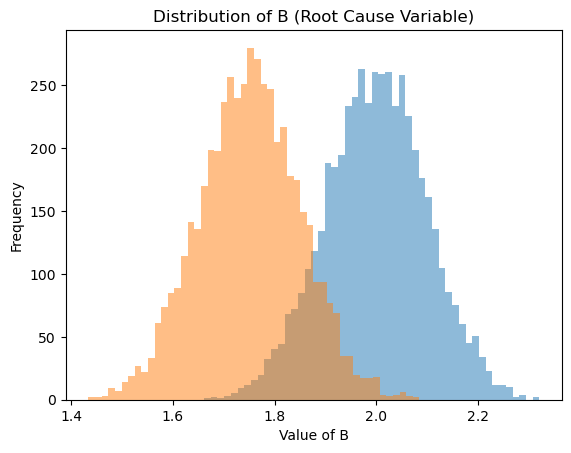

In [46]:
import matplotlib.pyplot as plt
index = 0
plt.hist(X_normal[:, index].cpu().numpy(), bins=50, alpha=0.5, label='B (Normal)')
plt.hist(X_faulty[:, index].cpu().numpy(), bins=50, alpha=0.5, label='B (Faulty)')
plt.title("Distribution of B (Root Cause Variable)")
plt.xlabel("Value of B")
plt.ylabel("Frequency") 

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# ---------------------------------------------------------
# 1. Synthetic Data: X -> Y (Amplified Causal Pair)
# ---------------------------------------------------------
def generate_2var_data(n=1000, anomaly=False):
    """
    Normal: X ~ N(0,1), Y = X^3
    Anomaly: X ~ N(2,1) (Shifted), Y = X^3 (Mechanism stays same)
    """
    if anomaly:
        X = np.random.normal(0.5, 1.5, 5*n) # Shifted
        # X = X[X > 0] # Keep only positive values to create a clear shift
        X = X[(X > 0.01) & (X < 1.0)][:n]
    else:
        X = np.random.normal(0.75, 1.5, 5*n) # Normal
        X = X[X > 0] # Keep only positive values to create a clear shift
        X = X[(X > 0.01) & (X < 1.0)][:n]

    # Y is the Downstream Effect (Amplified by Cubic mechanism)
    Y = X**(1/3) + np.random.normal(0, 0.1, len(X))
    
    data = np.stack([X, Y], axis=1)
    print(data.shape)
    return torch.tensor(data, dtype=torch.float32)

# ---------------------------------------------------------
# 2. Mechanistic Flow Architecture (with Latents)
# ---------------------------------------------------------
class VelocityField(nn.Module):
    def __init__(self, data_dim=2, latent_dim=2, hidden=128):
        super().__init__()
        # Input: Time (1) + Data (2) + Latent (2) = 5
        input_dim = 1 + data_dim + latent_dim
        # Output: Velocity for Data (2) + Velocity for Latent (2) = 4
        output_dim = data_dim + latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, output_dim)
        )

    def forward(self, t, xz):
        # xz contains both data and latents
        return self.net(torch.cat([t, xz], dim=-1))

# ---------------------------------------------------------
# 3. Training Logic (Local + Global + Distributional)
# ---------------------------------------------------------
def prepare_data_latent(src_data, tgt_data):
    """
    Augments data with Latent Z.
    src: [N, 2] -> [N, 4] (x, y, z1, z2)
    tgt: [N, 2] -> [N, 4]
    """
    bs = src_data.shape[0]
    device = src_data.device
    
    # Generate Latent Z shared for source and target
    # This acts as the "stochastic seed" for the restoration path
    z = torch.randn(bs, 2).to(device) * 1.0 # Standard latent noise
    
    src_aug = torch.cat([src_data, z], dim=1)
    tgt_aug = torch.cat([tgt_data, z], dim=1)
    
    return src_aug, tgt_aug

def train_mechanistic_flow(X_faulty, X_normal, lambda_g=10.0, lambda_dist=5.0, steps=2000):
    device = X_faulty.device
    src_aug, tgt_aug = prepare_data_latent(X_faulty, X_normal)
    
    model = VelocityField(data_dim=2, latent_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    integration_steps = 10
    dt = 1.0 / integration_steps
    
    print(f"Training Mechanistic Flow (Local + Global + Dist)...")
    
    for i in range(steps):
        optimizer.zero_grad()
        
        # --- A. Local CFM Loss ---
        # Sample random t, interpolate
        t_rand = torch.rand(src_aug.shape[0], 1).to(device)
        xt = (1 - t_rand) * src_aug + t_rand * tgt_aug
        vt = model(t_rand, xt)
        
        # Target velocity is straight path
        v_target = tgt_aug - src_aug
        loss_local = torch.mean((vt - v_target)**2)
        
        # --- B. Global L2 Loss (Trajectory Integration) ---
        # Simulate trajectory for the whole batch
        curr_x = src_aug.clone()
        for step in range(integration_steps):
            t_s = torch.ones(src_aug.shape[0], 1).to(device) * (step * dt)
            curr_x = curr_x + model(t_s, curr_x) * dt
            
        # Compare final transported point to actual target
        loss_global = torch.mean((curr_x - tgt_aug)**2)
        
        # --- C. Distributional Loss (Wasserstein Approx) ---
        # We want the distribution of restored data (curr_x) to match X_normal (tgt_aug)
        # We sort both and minimize MSE (sliced Wasserstein for 1D projections)
        loss_dist = 0
        for dim in range(2): # For X and Y dimensions
            pred_sorted, _ = torch.sort(curr_x[:, dim])
            target_sorted, _ = torch.sort(tgt_aug[:, dim])
            loss_dist += torch.mean((pred_sorted - target_sorted)**2)

        # Combine
        total_loss = loss_local + (lambda_g * loss_global) + (lambda_dist * loss_dist)
        
        total_loss.backward()
        optimizer.step()
        
        if i % 500 == 0:
            print(f"Iter {i:4d} | Loc: {loss_local:.4f} | Glob: {loss_global:.4f} | Dist: {loss_dist:.4f}")
            
    return model

# ---------------------------------------------------------
# 4. Jacobian RCA (Updated for Latents)
# ---------------------------------------------------------
def run_jacobian_rca(model, x_abnormal, labels):
    model.eval()
    
    # 1. Prepare Input: Abnormal Data + Frozen Latent
    # We only care about gradient w.r.t Data, so we detach Latents
    x_test = x_abnormal[:100].clone().detach().requires_grad_(True)
    
    # Append Zero Latents (or random) for evaluation
    z_fixed = torch.zeros(x_test.shape[0], 2).to(x_test.device)
    xz_input = torch.cat([x_test, z_fixed], dim=1)
    
    t_test = torch.full((x_test.shape[0], 1), 0.5).to(x_test.device)
    
    # 2. Forward Pass
    v_out = model(t_test, xz_input)
    
    # We only care about the velocity of the DATA dimensions (first 2)
    v_data = v_out[:, :2] 
    
    scores = []
    print(f"\n{'='*45}")
    print(f"{'Variable':<10} | {'Self-Corr (Diag)':<15} | {'Dependency (Off)'}")
    print(f"{'-'*45}")

    for i in range(len(labels)):
        # 3. Compute Gradients
        v_i_sum = v_data[:, i].sum()
        
        # We take gradient w.r.t x_test (the data part only)
        grad_v_i = torch.autograd.grad(v_i_sum, x_test, retain_graph=True)[0]
        
        # 4. Score Sparsity
        abs_grad = torch.abs(grad_v_i)
        
        diag = abs_grad[:, i]                 
        off_diag = abs_grad.sum(dim=1) - diag 
        
        # Autonomy Score
        autonomy = diag / (off_diag + 1e-8)
        
        avg_diag = diag.mean().item()
        avg_off = off_diag.mean().item()
        final_score = autonomy.mean().item()
        
        print(f"{labels[i]:<10} | {avg_diag:.4f}          | {avg_off:.4f}")
        scores.append(final_score)

    print(f"{'='*45}\n")
    return scores

# ---------------------------------------------------------
# 5. Main Execution
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cpu")
    labels = ['X', 'Y']
    
    # Generate Data
    X_normal = generate_2var_data(anomaly=False).to(device)
    X_faulty = generate_2var_data(anomaly=True).to(device) # X shifted, Y amplified

    # Train
    model = train_mechanistic_flow(X_faulty, X_normal, steps=2000)

    # Run Analysis
    scores = run_jacobian_rca(model, X_faulty, labels)
    
    # Result
    results = sorted(zip(labels, scores), key=lambda x: x[1], reverse=True)
    print("FINAL RANKING:")
    for rank, (name, score) in enumerate(results, 1):
        role = "[ROOT CAUSE]" if name == 'X' else "[EFFECT]"
        print(f"Rank {rank}: {name} (Score: {score:.1f}) <-- {role}")

(1000, 2)
(1000, 2)
Training Mechanistic Flow (Local + Global + Dist)...
Iter    0 | Loc: 0.0628 | Glob: 0.0621 | Dist: 0.0035
Iter  500 | Loc: 0.0616 | Glob: 0.0403 | Dist: 0.0111
Iter 1000 | Loc: 0.0610 | Glob: 0.0387 | Dist: 0.0105
Iter 1500 | Loc: 0.0593 | Glob: 0.0369 | Dist: 0.0093


KeyboardInterrupt: 

In [22]:
"""
Last Modified - 05/21/2026
Synthetic root-cause analysis benchmark using flow matching.

This script generates paired normal/faulty 2D samples from configurable source
distributions p_X and mechanisms f(x), injects a fault into one coordinate,
trains a small flow-matching model to predict the transport field from normal
to faulty samples, and then audits the learned field by computing an entropy-
based score R(Z) = H(v_Z) - log(sigma_Z) for each coordinate.

The score is used to rank the most likely root-cause variable. The script
supports both single-run experiments and a full benchmark over multiple
source distributions and mechanisms.
"""

import torch
import torch.nn as nn
import numpy as np
from scipy.stats import norm, gaussian_kde
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. INPUT DISTRIBUTIONS
# ==========================================
def sample_pX(dist, n, sigma=1):
    if dist == "A":
        x = np.random.uniform(0,1, n)
    elif dist == "B":
        x = np.random.normal(0, sigma, n)
    elif dist == "C":
        x = np.random.normal(0.5, sigma, n)
    elif dist == "D":
        x = np.random.normal(1.0, sigma, n)
    elif dist == "E":
        which = np.random.binomial(1, 0.5, n)
        x     = which * np.random.normal(0.3, sigma, n) + \
                (1 - which) * np.random.normal(0.7, sigma, n)
    return np.clip(x, 0, 1)

# ==========================================
# 2. MECHANISMS
# ==========================================
def make_s5():
    alphas = np.random.dirichlet(np.ones(5))
    mus    = np.random.uniform(0, 1, 5)
    sigmas = np.random.uniform(0, 0.1, 5)

    def s5(x):
        result = np.zeros_like(x)
        for i in range(5):
            result += alphas[i] * norm.cdf(x, loc=mus[i],
                                           scale=sigmas[i] + 1e-6)
        return result
    return s5

def apply_f(x, func, s5_fn=None):
    if func == "a":
        return np.cbrt(x)
    elif func == "b":
        return np.sqrt(np.abs(x) + 1e-8)
    elif func == "c":
        return x**2
    elif func == "d":
        return x**3
    elif func == "e":
        return s5_fn(x)

# ==========================================
# 3. DATA GENERATION
# ==========================================
def generate_pair(n, px_dist, func, s5_fn,
                  fault_magnitude=1.0, lam=0.1, sigma=0.2):
    def make_data(fault_x):
        x = sample_pX(px_dist, n, sigma=sigma) + fault_x
        x = np.clip(x, 0, 1 + fault_x)
        y = apply_f(x, func, s5_fn) + \
            lam * np.random.normal(0, sigma, n)
        X = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
        Y = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

        return torch.cat([X, Y], dim=1)

    return make_data(0.0), make_data(fault_magnitude)

# ==========================================
# 4. FLOW MODEL
# ==========================================
class FlowModel2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128), nn.ELU(),
            nn.Linear(128, 128), nn.ELU(),
            nn.Linear(128, 128), nn.ELU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

# ==========================================
# 5. TRAINING
# ==========================================
def train_flow(p_n_fn, p_f_fn, epochs=1000, batch=256):
    model = FlowModel2D().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        p_n      = p_n_fn(batch)
        p_f      = p_f_fn(batch)
        t        = torch.rand(batch, 1).to(device)
        x_t      = (1 - t) * p_n + t * p_f
        v_target = p_f - p_n
        loss     = nn.functional.mse_loss(model(x_t, t), v_target)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        if epoch % 200 == 0:
            print(f"  Epoch {epoch:>4} | Loss: {loss.item():.4f}")

    return model

# ==========================================
# 6. AUDIT
# ==========================================
def compute_entropy(v):
    kde = gaussian_kde(v)
    return -np.mean(kde.logpdf(v))


def audit(model, p_n, p_f, node_names=["X", "Y"], verbose=False):
    model.eval()
    n = len(p_n)
    with torch.no_grad():
        t    = torch.ones(n, 1).to(device) * 0.5
        x_t  = (1 - t) * p_n + t * p_f
        vels = model(x_t, t).cpu().numpy()

    # R(Z) = H(v_Z) - log(sigma_Z)
    entropies = {name: compute_entropy(vels[:, i])
                 for i, name in enumerate(node_names)}
    sigmas    = {name: np.std(vels[:, i])
                 for i, name in enumerate(node_names)}
    scores    = {}

    for name in node_names:
        if sigmas[name] < 1e-8:
            scores[name] = -np.inf   # degenerate — no fault signal
        else:
            scores[name] = entropies[name] - np.log(sigmas[name])

    predicted = max(scores, key=scores.get)

    if verbose:
        print(f"\n  {'Node':<6} {'H(v)':>10} {'sigma':>10} "
              f"{'log(sigma)':>12} {'R(Z)':>10}")
        print(f"  {'-'*52}")
        for name in node_names:
            if sigmas[name] < 1e-8:
                print(f"  {name:<6} {entropies[name]:>10.4f} "
                      f"{'—':>10} {'—':>12} {'degenerate':>10}")
            else:
                print(f"  {name:<6} {entropies[name]:>10.4f} "
                      f"{sigmas[name]:>10.4f} "
                      f"{np.log(sigmas[name]):>12.4f} "
                      f"{scores[name]:>10.4f}")
        print(f"\n  PREDICTED ROOT CAUSE: {predicted}")


    # ── Compute E[v_Z] after extracting velocities ────────────────
    model.eval()
    with torch.no_grad():
        t = torch.zeros(len(p_f), 1).to(device)
        V = model(p_f, t).cpu().numpy()

    e_vx = np.mean(V[:, 0])   # E[v_X]
    e_vy = np.mean(V[:, 1])   # E[v_Y]

    print(f"E[v_X] = {e_vx:.4f}")
    print(f"E[v_Y] = {e_vy:.4f}")
    print(f"E[v_X] ≈ 0: {'✓' if abs(e_vx) < 0.1 else '✗'}")


    return predicted, scores



# ==========================================
# 7. SINGLE EXPERIMENT
# ==========================================
def run_experiment(px_dist, func, n=1000,
                   fault_magnitude=1.0, lam=0.1, sigma=0.2,
                   epochs=1000, verbose=False):
    s5_fn = make_s5() if func == "e" else None

    def p_n_fn(batch):
        p_n, _ = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        return p_n

    def p_f_fn(batch):
        _, p_f = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        return p_f

    model = train_flow(p_n_fn, p_f_fn, epochs=epochs)
    p_n, p_f = generate_pair(n, px_dist, func, s5_fn,
                             fault_magnitude, lam, sigma)
    
    # plt.figure()
    # plt.title("Distribution of X: Normal vs Faulty")
    # plt.plot(p_n[:,0].cpu(), p_n[:,1].cpu(), 'o', alpha=0.5, label='Normal')
    # plt.plot(p_f[:,0].cpu(), p_f[:,1].cpu(), 'o', alpha=0.5, label='Faulty')
    # plt.legend()
    
    predicted, scores = audit(model, p_n, p_f, verbose=verbose)
    return predicted == "X", predicted, scores

# ==========================================
# 8. BENCHMARK
# ==========================================
PX_DISTS = ["A", "B", "C", "D", "E"]
FUNCS    = ["a", "b", "c", "d", "e"]

PX_NAMES = {
    "A": "U(0,1)",
    "B": "N(0,σ²)",
    "C": "N(0.5,σ²)",
    "D": "N(1,σ²)",
    "E": "GM([0.3,0.7])"
}

FUNC_NAMES = {
    "a": "x^(1/3)",
    "b": "x^(1/2)",
    "c": "x²",
    "d": "x³",
    "e": "s5(x)"
}

def run_benchmark(n=1000, fault_magnitude=1.0, lam=0.1,
                  sigma=0.2, epochs=1000, repeats=100):
    print("\n" + "█"*72)
    print("  DANIUSIS ET AL. BENCHMARK — FLOW MATCHING RCA")
    print(f"  n={n}, fault={fault_magnitude}, λ={lam}, "
          f"σ={sigma}, epochs={epochs}, repeats={repeats}")
    print("█"*72)

    print(f"\n  {'p_X':<18} {'f(x)':<12} {'Acc':>8}  "
          f"{'Correct':>8}  {'Wrong':>8}")
    print(f"  {'-'*58}")

    all_results = {}
    for px in PX_DISTS:
        for f in FUNCS:
            correct_count = 0
            for _ in range(repeats):
                correct, _, _ = run_experiment(
                    px_dist=px, func=f, n=n,
                    fault_magnitude=fault_magnitude,
                    lam=lam, sigma=sigma, epochs=epochs
                )
                if correct:
                    correct_count += 1

            acc = correct_count / repeats * 100
            all_results[(px, f)] = acc
            print(f"  {PX_NAMES[px]:<18} {FUNC_NAMES[f]:<12} "
                  f"{acc:>7.1f}%  {correct_count:>8}  "
                  f"{repeats - correct_count:>8}")

    overall = np.mean(list(all_results.values()))
    print(f"\n  {'─'*58}")
    print(f"  {'Overall Accuracy':<30} {overall:>7.1f}%")

    # Summary table
    print(f"\n  ACCURACY TABLE (rows=p_X, cols=f)")
    print(f"  {'':18}", end="")
    for f in FUNCS:
        print(f"  {FUNC_NAMES[f]:>9}", end="")
    print()
    print(f"  {'-'*70}")
    for px in PX_DISTS:
        print(f"  {PX_NAMES[px]:<18}", end="")
        for f in FUNCS:
            print(f"  {all_results[(px, f)]:>8.1f}%", end="")
        print()
    print("█"*72)

    return all_results

# ==========================================
# 9. MAIN — Jupyter compatible
# ==========================================

# ── Configure here ────────────────────────
MODE           = "single"    # "single" or "benchmark"

# Single experiment settings
PX             = "E"         # A, B, C, D, E
FUNC           = "a"         # a, b, c, d, e
FAULT          = 1
LAM            = 0.1
SIGMA          = 2
EPOCHS         = 1000
N              = 1000

# Benchmark additional settings
REPEATS        = 100         # repeats per combination
# ─────────────────────────────────────────

if MODE == "single":
    print(f"\n  Single experiment")
    print(f"  p_X={PX_NAMES[PX]}, f={FUNC_NAMES[FUNC]}, "
          f"fault={FAULT}, λ={LAM}, σ={SIGMA}, epochs={EPOCHS}")
    correct, predicted, scores = run_experiment(
        px_dist=PX, func=FUNC, n=N,
        fault_magnitude=FAULT, lam=LAM,
        sigma=SIGMA, epochs=EPOCHS, verbose=True
    )
    print(f"\n  True RC  : X")
    print(f"  Predicted: {predicted}  "
          f"{'✓ Correct' if correct else '✗ Wrong'}")

elif MODE == "benchmark":
    all_results = run_benchmark(
        n=N, fault_magnitude=FAULT, lam=LAM,
        sigma=SIGMA, epochs=EPOCHS, repeats=REPEATS
    )


  Single experiment
  p_X=GM([0.3,0.7]), f=x^(1/3), fault=1, λ=0.1, σ=2, epochs=1000
  Epoch    0 | Loss: 1.1764
  Epoch  200 | Loss: 0.2650
  Epoch  400 | Loss: 0.2079
  Epoch  600 | Loss: 0.2136
  Epoch  800 | Loss: 0.2191

  Node         H(v)      sigma   log(sigma)       R(Z)
  ----------------------------------------------------
  X          0.1847     0.2951      -1.2203     1.4050
  Y         -0.0002     0.2770      -1.2839     1.2837

  PREDICTED ROOT CAUSE: X
E[v_X] = 0.6279
E[v_Y] = 0.0297
E[v_X] ≈ 0: ✗

  True RC  : X
  Predicted: X  ✓ Correct


In [7]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# ── Log transform + StandardScaler preprocessing ─────────────
def preprocess(p_n_raw, p_f_raw):
    """
    Apply log1p transform followed by StandardScaler.
    Scaler fitted on normal data only, applied to both.
    
    log1p handles zeros safely: log1p(x) = log(1 + x)
    """
    p_n_np = p_n_raw.cpu().numpy() if torch.is_tensor(p_n_raw) \
             else np.array(p_n_raw)
    p_f_np = p_f_raw.cpu().numpy() if torch.is_tensor(p_f_raw) \
             else np.array(p_f_raw)

    # Step 1 — log1p transform
    p_n_log = np.log1p(np.abs(p_n_np)) * np.sign(p_n_np)
    p_f_log = np.log1p(np.abs(p_f_np)) * np.sign(p_f_np)

    # Step 2 — StandardScaler on normal only
    scaler  = StandardScaler()
    p_n_sc  = scaler.fit_transform(p_n_log)
    p_f_sc  = scaler.transform(p_f_log)

    p_n_t = torch.tensor(p_n_sc, dtype=torch.float32).to(device)
    p_f_t = torch.tensor(p_f_sc, dtype=torch.float32).to(device)

    return p_n_t, p_f_t, scaler

# ── Run single experiment with preprocessing ─────────────────
def run_experiment_scaled(px_dist, func, n=1000,
                          fault_magnitude=1.0, lam=0.1,
                          sigma=0.2, epochs=1000, verbose=False):
    s5_fn = make_s5() if func == "e" else None

    # Generate raw data
    def p_n_fn(batch):
        p_n, _ = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        return p_n

    def p_f_fn(batch):
        _, p_f = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        return p_f

    # Generate full datasets for preprocessing
    p_n_raw, p_f_raw = generate_pair(n, px_dist, func, s5_fn,
                                     fault_magnitude, lam, sigma)

    # Preprocess
    p_n, p_f, scaler = preprocess(p_n_raw, p_f_raw)

    # Preprocessed batch generators for training
    def p_n_fn_sc(batch):
        raw, _ = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        raw_np = raw.cpu().numpy()
        raw_log = np.log1p(np.abs(raw_np)) * np.sign(raw_np)
        return torch.tensor(
            scaler.transform(raw_log),
            dtype=torch.float32).to(device)

    def p_f_fn_sc(batch):
        _, raw = generate_pair(batch, px_dist, func, s5_fn,
                               fault_magnitude, lam, sigma)
        raw_np = raw.cpu().numpy()
        raw_log = np.log1p(np.abs(raw_np)) * np.sign(raw_np)
        return torch.tensor(
            scaler.transform(raw_log),
            dtype=torch.float32).to(device)

    # Train flow on preprocessed data
    model = train_flow(p_n_fn_sc, p_f_fn_sc, epochs=epochs)

    # Audit
    predicted, scores = audit(model, p_n, p_f, verbose=verbose)
    correct = predicted == "X"
    return correct, predicted, scores

# ── Run benchmark with preprocessing ─────────────────────────
def run_benchmark_scaled(n=1000, fault_magnitude=1.0, lam=0.1,
                         sigma=0.2, epochs=1000, repeats=10):
    print("\n" + "█"*72)
    print("  BENCHMARK — log1p + StandardScaler preprocessing")
    print(f"  n={n}, fault={fault_magnitude}, λ={lam}, "
          f"σ={sigma}, epochs={epochs}, repeats={repeats}")
    print("█"*72)

    print(f"\n  {'p_X':<18} {'f(x)':<12} {'Acc':>8}  "
          f"{'Correct':>8}  {'Wrong':>8}")
    print(f"  {'-'*58}")

    all_results = {}
    for px in PX_DISTS:
        for f in FUNCS:
            correct_count = 0
            for _ in range(repeats):
                correct, _, _ = run_experiment_scaled(
                    px_dist=px, func=f, n=n,
                    fault_magnitude=fault_magnitude,
                    lam=lam, sigma=sigma, epochs=epochs
                )
                if correct:
                    correct_count += 1

            acc = correct_count / repeats * 100
            all_results[(px, f)] = acc
            print(f"  {PX_NAMES[px]:<18} {FUNC_NAMES[f]:<12} "
                  f"{acc:>7.1f}%  {correct_count:>8}  "
                  f"{repeats-correct_count:>8}")

    overall = np.mean(list(all_results.values()))
    print(f"\n  {'─'*58}")
    print(f"  {'Overall Accuracy':<30} {overall:>7.1f}%")
    print("█"*72)
    return all_results

# ── Run ───────────────────────────────────────────────────────
# results_scaled = run_benchmark_scaled(
#     n              = 1000,
#     fault_magnitude = 1.0,
#     lam            = 0.1,
#     sigma          = 0.2,
#     epochs         = 1000,
#     repeats        = 10
# )

correct, predicted, scores = run_experiment_scaled(
    px_dist        = PX,    # U(0,1)
    func           = FUNC,    # x²
    n              = 1000,
    fault_magnitude = 2,
    lam            = 0.1,
    sigma          = 0.2,
    epochs         = 1000,
    verbose        = True    # prints the score table
)

print(f"\n  Single experiment")
print(f"  p_X={PX_NAMES[PX]}, f={FUNC_NAMES[FUNC]}, "
        f"fault={FAULT}, λ={LAM}, σ={SIGMA}, epochs={EPOCHS}")

print(f"\nTrue RC  : X")
print(f"Predicted: {predicted}  {'✓' if correct else '✗'}")

  Epoch    0 | Loss: 198.8592
  Epoch  200 | Loss: 0.8639
  Epoch  400 | Loss: 0.7527
  Epoch  600 | Loss: 0.7730
  Epoch  800 | Loss: 0.7353

  Node         H(v)      sigma   log(sigma)       R(Z)
  ----------------------------------------------------
  X         -4.8932     0.0021      -6.1580     1.2648
  Y         -2.2662     0.0257      -3.6604     1.3942

  PREDICTED ROOT CAUSE: Y

  Single experiment
  p_X=U(0,1), f=x^(1/3), fault=1, λ=0.1, σ=2, epochs=1000

True RC  : X
Predicted: Y  ✗


In [11]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import gaussian_kde

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. DATA GENERATION — N-node chain
# ==========================================
def gen_chain(n=256, fault_node=0, fault_magnitude=2.0,
              func_choices=None, n_vars=5):
    """
    Generates a chain of n_vars nodes:
    X1 -> X2 -> ... -> Xn

    fault_node     : 1-indexed node to inject fault, 0 = no fault
    fault_magnitude: size of the additive fault
    func_choices   : list of n_vars-1 ints, one per edge
                     1=x^(1/3)  2=tanh  3=cubic  4=sin  5=x^2  6=x^3
    n_vars         : number of nodes in the chain
    """
    assert func_choices is not None, "Must specify func_choices"
    assert len(func_choices) == n_vars - 1, \
        f"Need {n_vars-1} mechanisms for {n_vars} nodes, " \
        f"got {len(func_choices)}"

    def apply_mechanism(x, fc):
        if fc == 1:
            return 0.5 * torch.sign(x) * torch.abs(x + 1e-8)**(1/3)
        elif fc == 2:
            return 2 * torch.tanh(2 * x)
        elif fc == 3:
            return 0.5 * x**3 - 1.5 * x**2 + x
        elif fc == 4:
            return torch.sin(2 * x)
        elif fc == 5:
            return 0.5 * x**2
        elif fc == 6:
            return 0.5 * x**3
        else:
            raise ValueError(f"Unknown mechanism code: {fc}")

    def fault(node_idx):
        return fault_magnitude if node_idx == fault_node else 0.0

    # First node
    nodes = []
    x = torch.empty(n, 1).uniform_(0.0, 3.0).to(device) + fault(1)
    nodes.append(x)

    # Downstream nodes
    for i in range(n_vars - 1):
        x = apply_mechanism(nodes[i], func_choices[i]) \
            + fault(i + 2) \
            + 0.1 * torch.randn(n, 1).to(device)
        nodes.append(x)

    return torch.cat(nodes, dim=1)

# ==========================================
# 2. FLOW MODEL
# ==========================================
class FlowModelND(nn.Module):
    def __init__(self, n_vars):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_vars + 1, 256), nn.ELU(),
            nn.Linear(256, 256),        nn.ELU(),
            nn.Linear(256, 256),        nn.ELU(),
            nn.Linear(256, n_vars)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

# ==========================================
# 3. TRAINING
# ==========================================
def train_model(fault_node, n_vars, fault_magnitude=2.0,
                func_choices=None, epochs=3000, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    model = FlowModelND(n_vars=n_vars).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        p_n = gen_chain(256, fault_node=0,
                        fault_magnitude=0.0,
                        func_choices=func_choices,
                        n_vars=n_vars)
        p_f = gen_chain(256, fault_node=fault_node,
                        fault_magnitude=fault_magnitude,
                        func_choices=func_choices,
                        n_vars=n_vars)

        t        = torch.rand(256, 1).to(device)
        x_t      = (1 - t) * p_n + t * p_f
        v_target = p_f - p_n

        loss = nn.functional.mse_loss(model(x_t, t), v_target)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        if epoch % 1000 == 0:
            print(f"    Epoch {epoch:>4} | Loss: {loss.item():.4f}")

    return model

# ==========================================
# 4. AUDIT
# ==========================================
def compute_entropy(v):
    kde = gaussian_kde(v)
    return -np.mean(kde.logpdf(v))

def audit(velocities, true_fault_node=None, node_names=None, verbose=True):
    """
    Computes both criteria side by side:
      H(Z)  = H(v_Z)               — raw entropy
      R(Z)  = H(v_Z) - log(sigma)  — entropy of standardized velocity

    Root cause reported for both.
    """
    if node_names is None:
        node_names = [f"X{i+1}" for i in range(velocities.shape[1])]

    h_scores = {}   # raw entropy
    r_scores = {}   # entropy - log(sigma)

    if verbose:
        print(f"\n  {'Node':<6} {'H(v)':>10} {'sigma':>10} "
              f"{'log(sigma)':>12} {'R(Z)':>10}  {'True RC'}")
        print(f"  {'-'*62}")

    for i, name in enumerate(node_names):
        v_i   = velocities[:, i]
        sigma = np.std(v_i)
        h     = compute_entropy(v_i)
        tag   = "  ← TRUE RC" if name == f"X{true_fault_node}" else ""

        if sigma < 1e-8:
            if verbose:
                print(f"  {name:<6} {h:>10.4f} {'—':>10} "
                      f"{'—':>12} {'degenerate':>10}{tag}")
            continue

        log_sigma       = np.log(sigma)
        r               = h - log_sigma
        h_scores[name]  = h
        r_scores[name]  = r

        if verbose:
            print(f"  {name:<6} {h:>10.4f} {sigma:>10.4f} "
                  f"{log_sigma:>12.4f} {r:>10.4f}{tag}")

    # ── Predictions ───────────────────────────────────────────────
    pred_h = max(h_scores, key=h_scores.get) if h_scores else None
    pred_r = max(r_scores, key=r_scores.get) if r_scores else None

    true_name = f"X{true_fault_node}" if true_fault_node else None

    correct_h = (pred_h == true_name) if true_name else None
    correct_r = (pred_r == true_name) if true_name else None

    if verbose:
        print(f"  {'-'*62}")
        h_res = ("✓" if correct_h else "✗") if correct_h is not None else ""
        r_res = ("✓" if correct_r else "✗") if correct_r is not None else ""
        print(f"  PREDICTED (H)    : {pred_h}  {h_res}")
        print(f"  PREDICTED (R)    : {pred_r}  {r_res}")

    return h_scores, r_scores, pred_h, pred_r, correct_h, correct_r

# ==========================================
# 5. EVALUATE
# ==========================================
def evaluate(model, fault_node, n_vars, fault_magnitude=2.0,
             func_choices=None, n_test=2000, verbose=True):
    node_names = [f"X{i+1}" for i in range(n_vars)]

    model.eval()
    with torch.no_grad():
        p_n  = gen_chain(n_test, fault_node=0,
                         fault_magnitude=0.0,
                         func_choices=func_choices,
                         n_vars=n_vars)
        p_f  = gen_chain(n_test, fault_node=fault_node,
                         fault_magnitude=fault_magnitude,
                         func_choices=func_choices,
                         n_vars=n_vars)
        t    = torch.ones(n_test, 1).to(device) * 0.5
        x_t  = (1 - t) * p_n + t * p_f
        vels = model(x_t, t).cpu().numpy()

    return audit(vels, true_fault_node=fault_node,
                 node_names=node_names, verbose=verbose)



# ==========================================
# 6. MAIN — configure here
# ==========================================
if __name__ == "__main__":

    # ── Configuration ─────────────────────────────────────────────
    N_VARS          = 4            # number of nodes: 2, 3, 4, or 5
    FAULT_MAGNITUDE = 2.0
    EPOCHS          = 3000
    SEED            = 42

    # One mechanism per edge (length must be N_VARS - 1)
    # 1=x^(1/3)  2=tanh  3=cubic  4=sin  5=x^2  6=x^3
    FUNC_CHOICES = [5, 2, 1]             # N_VARS=2: one edge X1->X2
    # FUNC_CHOICES = [5, 2]        # N_VARS=3
    # FUNC_CHOICES = [5, 2, 6]     # N_VARS=4
    # FUNC_CHOICES = [5, 2, 6, 4]  # N_VARS=5

    MECHANISM_NAMES = {
        1: "x^(1/3)", 2: "tanh",  3: "cubic",
        4: "sin",     5: "x^2",   6: "x^3"
    }

    # ── Header ────────────────────────────────────────────────────
    chain_str = " → ".join([f"X{i+1}" for i in range(N_VARS)])
    mech_str  = " | ".join(
        [f"X{i+1}→X{i+2}: {MECHANISM_NAMES[FUNC_CHOICES[i]]}"
         for i in range(N_VARS - 1)])

    print("█"*62)
    print("  FLOW MATCHING RCA — CHAIN EXPERIMENT")
    print("  R(Z) = H(v_Z) - log(sigma_Z)")
    print(f"  Chain      : {chain_str}")
    print(f"  Mechanisms : {mech_str}")
    print(f"  Magnitude  : {FAULT_MAGNITUDE}")
    print(f"  Epochs     : {EPOCHS}")
    print("█"*62)

    # ── Test all fault locations ───────────────────────────────────
    results = []
    for fault_node in range(1, N_VARS + 1):
        print(f"\n{'─'*62}")
        print(f"  Training: fault at X{fault_node} ...")
        print(f"{'─'*62}")

        model = train_model(
            fault_node      = fault_node,
            n_vars          = N_VARS,
            fault_magnitude = FAULT_MAGNITUDE,
            func_choices    = FUNC_CHOICES,
            epochs          = EPOCHS,
            seed            = SEED
        )

        h_scores, r_scores, pred_h, pred_r, correct_h, correct_r = evaluate(
            model,
            fault_node      = fault_node,
            n_vars          = N_VARS,
            fault_magnitude = FAULT_MAGNITUDE,
            func_choices    = FUNC_CHOICES,
            verbose         = True
        )

        results.append((fault_node, pred_h, pred_r, correct_h, correct_r))

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n{'█'*70}")
    print(f"  SUMMARY")
    print(f"{'█'*70}")
    print(f"  {'True RC':<10} {'Pred(H)':<12} {'H':>4}  "
          f"{'Pred(R)':<12} {'R':>4}")
    print(f"  {'-'*52}")
    for fault_node, pred_h, pred_r, correct_h, correct_r in results:
        h_sym = "✓" if correct_h else "✗"
        r_sym = "✓" if correct_r else "✗"
        print(f"  X{fault_node:<9} {str(pred_h):<12} {h_sym:>4}  "
              f"{str(pred_r):<12} {r_sym:>4}")

    n_h = sum(c for _, _, _, c, _ in results)
    n_r = sum(c for _, _, _, _, c in results)
    n   = len(results)
    print(f"\n  Accuracy H : {n_h}/{n} ({100*n_h/n:.0f}%)")
    print(f"  Accuracy R : {n_r}/{n} ({100*n_r/n:.0f}%)")
    print(f"{'█'*70}")

██████████████████████████████████████████████████████████████
  FLOW MATCHING RCA — CHAIN EXPERIMENT
  R(Z) = H(v_Z) - log(sigma_Z)
  Chain      : X1 → X2 → X3 → X4
  Mechanisms : X1→X2: x^2 | X2→X3: tanh | X3→X4: x^(1/3)
  Magnitude  : 2.0
  Epochs     : 3000
██████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────
  Training: fault at X1 ...
──────────────────────────────────────────────────────────────
    Epoch    0 | Loss: 10.6267
    Epoch 1000 | Loss: 0.5372
    Epoch 2000 | Loss: 0.4289

  Node         H(v)      sigma   log(sigma)       R(Z)  True RC
  --------------------------------------------------------------
  X1         1.5749     1.2364       0.2122     1.3627  ← TRUE RC
  X2         2.5238     3.2998       1.1939     1.3299
  X3         0.6161     0.7689      -0.2627     0.8788
  X4        -0.8429     0.2257      -1.4887     0.6458
  --------------------------------------------------------------
  P